# Augmentation check -- both phases (water+fat, 2-channel input, 6-class output)

Sibling of the baseline-vs-augmentation comparison that already exists for the
other two phases: for water it lives in `unet_applied.ipynb`
(`baseline_dice_ce*` vs `data_aug_dice_ce*`), for fat in `unet_applied_fat.ipynb`
(`fat_baseline_dice_ce_s*` vs `fat_data_aug_dice_ce_s*`, which decided
augmentation ON for that phase: paired comparison on validation, n=8 patients,
macro Dice p=0.0078). Neither result is assumed to carry over here -- `phase='both'`
changes both the input (2 channels instead of 1) and the target (6 classes
instead of 5 or 2), and `AugmentedDataset`'s rotation/elastic-deform code had to
be changed to warp every channel identically (see `utils/data_loading.py`) to
even support this input shape, so this is genuinely new ground, not a rerun.

Loss is held fixed at `dice_ce` throughout, matching both existing
baseline-vs-aug comparisons -- augmentation is evaluated independently of the
loss-ablation question, which `both_phase_ablation.ipynb` answers separately
(and holds `AUGMENT` fixed at whatever this notebook concludes).

Same invariants as every other ablation-style notebook here:

1. **`split_seed` is frozen at 0** -- identical to `both_phase_ablation.ipynb`
   and `loss_ablation.ipynb`, so val/test patients are the same set everywhere.
2. **The test set is never touched** until baseline vs. augmented is decided.
3. **Selection runs on per-patient macro Dice**, not slice-wise Dice.

Every model here trains from scratch -- `phase='both'` changed the first conv
layer's input width and the output layer's class count, so there is nothing to
warm-start from an existing water-only or fat-only checkpoint.

`SEEDS = [0, 1, 2]`, matching the fat notebook's rigor (the water version only
ran one seed each, informally, before the seeded pattern was adopted).

## Setup

In [ ]:
import os

# point this at whichever GPU is free
os.environ["CUDA_VISIBLE_DEVICES"] = "7"
print(f"Targeting GPU: {os.environ['CUDA_VISIBLE_DEVICES']}")

Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7f5b16f8eaa0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 7f5ad8730df0, raw_cell="import os

# point this at whichever GPU is free
o.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Buoa-hpc/hpc/jgeo610/heart_segmentation/both_phase_augmentation.ipynb#W2sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


ConnectionResetError: Connection lost

Targeting GPU: 2
Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7f5b16f8eaa0>> (for post_run_cell), with arguments args (<ExecutionResult object at 7f5ad8732530, execution_count=11 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7f5ad8730df0, raw_cell="import os

# point this at whichever GPU is free
o.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Buoa-hpc/hpc/jgeo610/heart_segmentation/both_phase_augmentation.ipynb#W2sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


ConnectionResetError: Connection lost

In [12]:
import sys
sys.path.append('.')

import json
import logging
import numpy as np
import torch
from pathlib import Path

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7f5b16f8eaa0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 7f5fc9955ae0, raw_cell="import sys
sys.path.append('.')

import json
impor.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Buoa-hpc/hpc/jgeo610/heart_segmentation/both_phase_augmentation.ipynb#W3sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


ConnectionResetError: Connection lost

Using device: cuda
Tesla V100-PCIE-32GB
Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7f5b16f8eaa0>> (for post_run_cell), with arguments args (<ExecutionResult object at 7f5fc9955f00, execution_count=12 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7f5fc9955ae0, raw_cell="import sys
sys.path.append('.')

import json
impor.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Buoa-hpc/hpc/jgeo610/heart_segmentation/both_phase_augmentation.ipynb#W3sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


ConnectionResetError: Connection lost

In [13]:
import train
from unet import UNet
from utils import metrics
from utils.data_loading import VolumeMRIDataset, AugmentedDataset

train.dir_img = Path('./data/imgs/')
train.dir_mask = Path('./data/masks/')
train.dir_checkpoint = Path('./checkpoints/')

Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7f5b16f8eaa0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 7f5fc9988ca0, raw_cell="import train
from unet import UNet
from utils impo.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Buoa-hpc/hpc/jgeo610/heart_segmentation/both_phase_augmentation.ipynb#W4sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


ConnectionResetError: Connection lost

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7f5b16f8eaa0>> (for post_run_cell), with arguments args (<ExecutionResult object at 7f5fc9988970, execution_count=13 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7f5fc9988ca0, raw_cell="import train
from unet import UNet
from utils impo.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Buoa-hpc/hpc/jgeo610/heart_segmentation/both_phase_augmentation.ipynb#W4sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


ConnectionResetError: Connection lost

## Experiment configuration

`LOSS` is fixed -- this notebook isolates the augmentation effect, the same way
`both_phase_ablation.ipynb` isolates the loss effect by holding augmentation
fixed. `dice_ce` matches the loss both existing baseline-vs-aug comparisons used.

In [14]:
PHASE      = 'both'
LOSS       = 'dice_ce'
SEEDS      = [0, 1, 2]

SPLIT_SEED   = 0        # FROZEN. Identical to both_phase_ablation.ipynb -- do not change.
EPOCHS       = 40
BATCH_SIZE   = 8
LR           = 1e-5
IMG_SCALE    = 1.0
N_CLASSES    = train.PHASE_N_CLASSES[PHASE]     # 6 for 'both' (bg + LV/RV/LA/RA/EAT)
N_CHANNELS   = train.PHASE_N_CHANNELS[PHASE]    # 2 for 'both' (water, fat)
AMP          = True
SELECT_ON    = 'macro_dice'
LR_SCHEDULE  = 'poly'
VAL_PERCENT  = 0.15
TEST_PERCENT = 0.15

def baseline_run_name(seed):
    return f'baseline_{LOSS}_s{seed}'

def aug_run_name(seed):
    return f'data_aug_{LOSS}_s{seed}'

# train_model prefixes non-water run names with '{phase}_' internally (water
# itself stays unprefixed -- see CLAUDE.md). Any cell here that builds a
# checkpoint path ITSELF, rather than going through train_model, has to
# replicate that rule or its bookkeeping will look in the wrong directory.
# Identical helper to both_phase_ablation.ipynb / loss_ablation_fat.ipynb.
def run_dir_for(run_name):
    return train.dir_checkpoint / (run_name if PHASE == 'water' else f'{PHASE}_{run_name}')

print(f'{len(SEEDS)} seeds {SEEDS}, {EPOCHS} epochs each, baseline + augmented:')
for seed in SEEDS:
    print(f'  {run_dir_for(baseline_run_name(seed)).name:<28} (augment=False)')
    print(f'  {run_dir_for(aug_run_name(seed)).name:<28} (augment=True)')

Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7f5b16f8eaa0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 7f5ae816ae90, raw_cell="PHASE      = 'both'
LOSS       = 'dice_ce'
SEEDS  .." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Buoa-hpc/hpc/jgeo610/heart_segmentation/both_phase_augmentation.ipynb#W6sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


ConnectionResetError: Connection lost

3 seeds [0, 1, 2], 40 epochs each, baseline + augmented:
  both_baseline_dice_ce_s0     (augment=False)
  both_data_aug_dice_ce_s0     (augment=True)
  both_baseline_dice_ce_s1     (augment=False)
  both_data_aug_dice_ce_s1     (augment=True)
  both_baseline_dice_ce_s2     (augment=False)
  both_data_aug_dice_ce_s2     (augment=True)
Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7f5b16f8eaa0>> (for post_run_cell), with arguments args (<ExecutionResult object at 7f5fc998bd60, execution_count=14 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7f5ae816ae90, raw_cell="PHASE      = 'both'
LOSS       = 'dice_ce'
SEEDS  .." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Buoa-hpc/hpc/jgeo610/heart_segmentation/both_phase_augmentation.ipynb#W6sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


ConnectionResetError: Connection lost

## Dataset

Built **once**, passed into every run via `dataset=`. `VolumeMRIDataset(..., phase='both')`
stacks the water and fat halves of each DICOM as a 2-channel image and keeps
all 6 mask labels; cached to `data/preprocessed_cache/` under `_both`-suffixed
filenames shared with `both_phase_ablation.ipynb` (same phase, same cache).

In [15]:
dataset = VolumeMRIDataset(train.dir_img, train.dir_mask, scale=IMG_SCALE, phase=PHASE)
print(f'{len(dataset.mask_file_for)} patients, {len(dataset.index)} slices')
print(f'mask values: {dataset.mask_values}')

Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7f5b16f8eaa0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 7f5fc99cd000, raw_cell="dataset = VolumeMRIDataset(train.dir_img, train.di.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Buoa-hpc/hpc/jgeo610/heart_segmentation/both_phase_augmentation.ipynb#X11sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


ConnectionResetError: Connection lost

INFO: Found 50 patients, 4748 total slices
INFO: Scanning mask files to determine unique values...
INFO: Unique mask values: [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]


50 patients, 4748 slices
mask values: [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]
Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7f5b16f8eaa0>> (for post_run_cell), with arguments args (<ExecutionResult object at 7f5fc99cd570, execution_count=15 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7f5fc99cd000, raw_cell="dataset = VolumeMRIDataset(train.dir_img, train.di.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Buoa-hpc/hpc/jgeo610/heart_segmentation/both_phase_augmentation.ipynb#X11sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


ConnectionResetError: Connection lost

### Confirm the split before spending any GPU time

Same patients as `both_phase_ablation.ipynb` since `split_seed` is identical --
this is what lets the two notebooks' results sit in the same comparison space.

In [16]:
train_idx, val_idx, test_idx = train.split_patients(
    dataset, val_percent=VAL_PERCENT, test_percent=TEST_PERCENT, seed=SPLIT_SEED
)

val_patients  = sorted({dataset.index[i][0] for i in val_idx})
test_patients = sorted({dataset.index[i][0] for i in test_idx})

print('val patients :', val_patients)
print('test patients:', test_patients, '  <- not scored until the final section')
print(f'slices -> train {len(train_idx)} / val {len(val_idx)} / test {len(test_idx)}')

pat = lambda idxs: {dataset.index[i][0] for i in idxs}
assert not (pat(train_idx) & pat(val_idx))
assert not (pat(train_idx) & pat(test_idx))
assert not (pat(val_idx) & pat(test_idx))
print('OK: train / val / test disjoint by patient')

Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7f5b16f8eaa0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 7f5fc998a920, raw_cell="train_idx, val_idx, test_idx = train.split_patient.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Buoa-hpc/hpc/jgeo610/heart_segmentation/both_phase_augmentation.ipynb#X13sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


ConnectionResetError: Connection lost

INFO: Patient-level split of 50 patients / 4748 slices (seed 0):
        train: 34 patients,  3232 slices
        val:    8 patients,   742 slices  ['CADRE_1382_second', 'CADRE_1395_second', 'CADRE_1671', 'CADRE_1855', 'CADRE_1857', 'CADRE_1861', 'CADRE_1872', 'CADRE_1875']
        test:   8 patients,   774 slices  ['CADRE_1113', 'CADRE_1116_first', 'CADRE_1523', 'CADRE_1532', 'CADRE_1743', 'CADRE_1744', 'CADRE_1859', 'CADRE_1867']


val patients : ['CADRE_1382_second', 'CADRE_1395_second', 'CADRE_1671', 'CADRE_1855', 'CADRE_1857', 'CADRE_1861', 'CADRE_1872', 'CADRE_1875']
test patients: ['CADRE_1113', 'CADRE_1116_first', 'CADRE_1523', 'CADRE_1532', 'CADRE_1743', 'CADRE_1744', 'CADRE_1859', 'CADRE_1867']   <- not scored until the final section
slices -> train 3232 / val 742 / test 774
OK: train / val / test disjoint by patient
Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7f5b16f8eaa0>> (for post_run_cell), with arguments args (<ExecutionResult object at 7f5fc99887c0, execution_count=16 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7f5fc998a920, raw_cell="train_idx, val_idx, test_idx = train.split_patient.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Buoa-hpc/hpc/jgeo610/heart_segmentation/both_phase_augmentation.ipynb#X13sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


ConnectionResetError: Connection lost

## Sanity check: augmentations on a 2-channel sample

Quick visual check that rotation/elastic-deform now warp both channels
identically, and contrast/noise perturb both independently -- this is what the
`utils/data_loading.py` fix (looping over channels instead of hardcoding
`img[0]`) is supposed to guarantee. Top row is the water channel, bottom row
the fat channel; both rows must show the same geometric warp under
rotation/elastic, and MAY differ under contrast/noise.

Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7f5b16f8eaa0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 7f5fc99f0d00, raw_cell="import matplotlib.pyplot as plt

train_set_preview.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Buoa-hpc/hpc/jgeo610/heart_segmentation/both_phase_augmentation.ipynb#X15sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:

ConnectionResetError: Connection lost

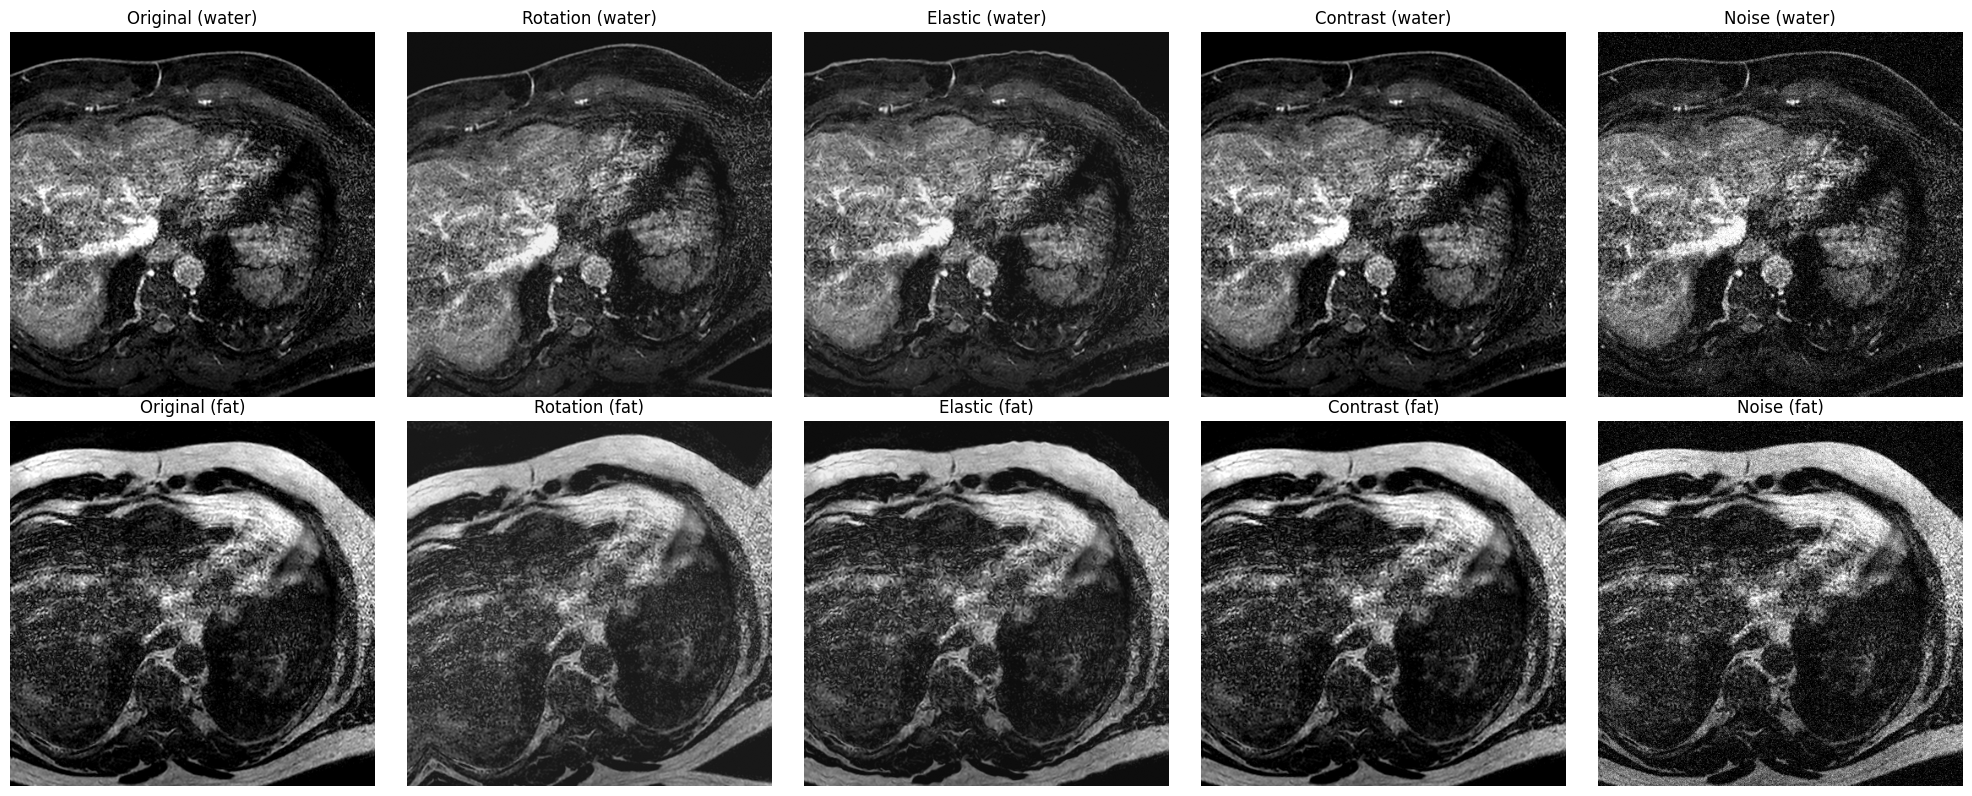

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7f5b16f8eaa0>> (for post_run_cell), with arguments args (<ExecutionResult object at 7f5fc99f04f0, execution_count=17 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7f5fc99f0d00, raw_cell="import matplotlib.pyplot as plt

train_set_preview.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Buoa-hpc/hpc/jgeo610/heart_segmentation/both_phase_augmentation.ipynb#X15sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


ConnectionResetError: Connection lost

In [17]:
import matplotlib.pyplot as plt

train_set_preview = torch.utils.data.Subset(dataset, train_idx)
sample0 = train_set_preview[0]

variants = [
    ('Original', dict(rotate_prob=0, elastic_prob=0, contrast_prob=0, noise_prob=0)),
    ('Rotation', dict(rotate_prob=1.0, elastic_prob=0, contrast_prob=0, noise_prob=0)),
    ('Elastic',  dict(rotate_prob=0, elastic_prob=1.0, contrast_prob=0, noise_prob=0)),
    ('Contrast', dict(rotate_prob=0, elastic_prob=0, contrast_prob=1.0, noise_prob=0)),
    ('Noise',    dict(rotate_prob=0, elastic_prob=0, contrast_prob=0, noise_prob=1.0)),
]

fig, axes = plt.subplots(2, len(variants), figsize=(4 * len(variants), 8))
for col, (title, probs) in enumerate(variants):
    if title == 'Original':
        img = sample0['image']
    else:
        img = AugmentedDataset(train_set_preview, **probs)[0]['image']
    axes[0, col].imshow(img[0], cmap='gray')
    axes[0, col].set_title(f'{title} (water)')
    axes[0, col].axis('off')
    axes[1, col].imshow(img[1], cmap='gray')
    axes[1, col].set_title(f'{title} (fat)')
    axes[1, col].axis('off')
plt.tight_layout()
plt.show()

## Train baseline (`augment=False`)

Resumable the same way as `both_phase_ablation.ipynb`'s `run_arm()`: a seed
whose `run_config.json` already has `'finished'` is reloaded rather than
retrained. Delete the run directory to force a genuine re-run.

In [18]:
import gc
import time

results = {}   # (kind, seed) -> train_model() result dict (or reloaded config)


def already_done(run_name):
    cfg = run_dir_for(run_name) / 'run_config.json'
    if not cfg.exists():
        return False
    try:
        return 'finished' in json.loads(cfg.read_text())
    except json.JSONDecodeError:
        return False


def run_variant(run_name, seed, augment, force=False):
    """Train one baseline/augmented variant. Everything except `augment` is
    shared with its counterpart at the same seed, so the two are comparable."""
    run_dir = run_dir_for(run_name)

    if already_done(run_name) and not force:
        cfg = json.loads((run_dir / 'run_config.json').read_text())
        print(f'{run_name} already finished (best epoch {cfg["best_epoch"]}, '
              f'macro Dice {cfg.get("best_val_macro_dice", float("nan")):.4f}).')
        print(f'Pass force=True or delete {run_dir} to re-run.')
        return cfg

    print(f'===== {run_name}  (augment={augment}) =====')
    t0 = time.time()

    train.set_seed(seed)          # BEFORE the model: UNet() consumes the torch RNG
    model = UNet(n_channels=N_CHANNELS, n_classes=N_CLASSES, bilinear=False)
    model = model.to(memory_format=torch.channels_last).to(device=device)

    res = train.train_model(
        model=model,
        device=device,
        dataset=dataset,
        loss=LOSS,
        phase=PHASE,               # dataset is passed explicitly, so this is the only
                                    # way train_model learns the phase (class_names,
                                    # run-name prefixing)
        seed=seed,
        split_seed=SPLIT_SEED,     # frozen
        select_on=SELECT_ON,
        lr_schedule=LR_SCHEDULE,
        run_name=run_name,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        learning_rate=LR,
        img_scale=IMG_SCALE,
        amp=AMP,
        augment=augment,           # <-- the only thing that varies between the two cells below
        val_percent=VAL_PERCENT,
        test_percent=TEST_PERCENT,
        eval_test=False,           # the test set stays sealed
    )

    print(f'\n{run_name}: best macro Dice {res["best_val_macro_dice"]:.4f} '
          f'@ epoch {res["best_epoch"]}  ({(time.time() - t0) / 60:.1f} min)')
    print(f'mean/SD across val patients -> {run_dir / "val_metrics_summary.csv"}')
    if 'val' in res.get('per_patient_metrics', {}):
        print(metrics.format_summary(res['per_patient_metrics']['val']['summary']))

    del model
    gc.collect()
    torch.cuda.empty_cache()
    return res


print('run_variant() ready. Run the baseline and augmented cells below one at a time.')

Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7f5b16f8eaa0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 7f5fc9662e00, raw_cell="import gc
import time

results = {}   # (kind, see.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Buoa-hpc/hpc/jgeo610/heart_segmentation/both_phase_augmentation.ipynb#X20sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


ConnectionResetError: Connection lost

run_variant() ready. Run the baseline and augmented cells below one at a time.
Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7f5b16f8eaa0>> (for post_run_cell), with arguments args (<ExecutionResult object at 7f5fc98c7250, execution_count=18 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7f5fc9662e00, raw_cell="import gc
import time

results = {}   # (kind, see.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Buoa-hpc/hpc/jgeo610/heart_segmentation/both_phase_augmentation.ipynb#X20sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


ConnectionResetError: Connection lost

In [19]:
baseline_results = {}
for seed in SEEDS:
    baseline_results[seed] = run_variant(baseline_run_name(seed), seed, augment=False)

Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7f5b16f8eaa0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 7f5fc99f3c70, raw_cell="baseline_results = {}
for seed in SEEDS:
    basel.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Buoa-hpc/hpc/jgeo610/heart_segmentation/both_phase_augmentation.ipynb#X21sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


ConnectionResetError: Connection lost

INFO: Seeded RNGs with 0


===== baseline_dice_ce_s0  (augment=False) =====


INFO: Seeded RNGs with 0
INFO: Patient-level split of 50 patients / 4748 slices (seed 0):
        train: 34 patients,  3232 slices
        val:    8 patients,   742 slices  ['CADRE_1382_second', 'CADRE_1395_second', 'CADRE_1671', 'CADRE_1855', 'CADRE_1857', 'CADRE_1861', 'CADRE_1872', 'CADRE_1875']
        test:   8 patients,   774 slices  ['CADRE_1113', 'CADRE_1116_first', 'CADRE_1523', 'CADRE_1532', 'CADRE_1743', 'CADRE_1744', 'CADRE_1859', 'CADRE_1867']
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


ConnectionResetError: Connection lost

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7f5b16f8eaa0>> (for post_run_cell), with arguments args (<ExecutionResult object at 7f5fc99f3d60, execution_count=19 error_before_exec=None error_in_exec=Connection lost info=<ExecutionInfo object at 7f5fc99f3c70, raw_cell="baseline_results = {}
for seed in SEEDS:
    basel.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Buoa-hpc/hpc/jgeo610/heart_segmentation/both_phase_augmentation.ipynb#X21sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


ConnectionResetError: Connection lost

## Train augmented (`augment=True`)

A fresh model per seed, seeded exactly like its baseline counterpart -- `augment`
is the only thing that differs between this cell and the one above at the same
seed.

In [ ]:
aug_results = {}
for seed in SEEDS:
    aug_results[seed] = run_variant(aug_run_name(seed), seed, augment=True)

## Results

### Per-run summary

Read back from disk rather than the in-memory result dicts, so this works on a
fresh kernel.

In [ ]:
def load_run(run_name):
    d = run_dir_for(run_name)
    cfg = json.loads((d / 'run_config.json').read_text())
    csv_path = d / 'val_metrics_per_patient.csv'
    rows = metrics.load_per_patient(csv_path) if csv_path.exists() else []
    return cfg, rows


PER_PATIENT_METRICS = metrics.DEFAULT_METRICS


def variant_rows(run_name_fn):
    """Per-patient rows for one variant (baseline or augmented), averaged over
    whatever seeds have finished -- same per-(patient, class) averaging as
    both_phase_ablation.ipynb's arm_rows(), and for the same reason: the same
    val patients scored 3 times are not 21 independent observations."""
    by_key, found = {}, []
    for seed in SEEDS:
        path = run_dir_for(run_name_fn(seed)) / 'val_metrics_per_patient.csv'
        if not path.exists():
            continue
        found.append(seed)
        for r in metrics.load_per_patient(path):
            by_key.setdefault((r['patient_id'], r['class_name']), []).append(r)

    out = []
    for (pid, cname), rs in sorted(by_key.items()):
        row = {'patient_id': pid, 'class_name': cname, 'cls': rs[0]['cls']}
        for m in PER_PATIENT_METRICS + ('voxel_ml',):
            if m not in rs[0]:
                continue
            vals = [r[m] for r in rs if np.isfinite(r[m])]
            row[m] = float(np.mean(vals)) if vals else float('nan')
        for m in ('gt_voxels', 'pred_voxels'):
            row[m] = int(np.mean([r[m] for r in rs]))
        row['missed'] = any(r['missed'] for r in rs)
        row['n_seeds'] = len(rs)
        out.append(row)
    return out, set(found)


VARIANTS = {'baseline': baseline_run_name, 'augmented': aug_run_name}

table = []
for label, run_name_fn in VARIANTS.items():
    for seed in SEEDS:
        run_name = run_name_fn(seed)
        if not (run_dir_for(run_name) / 'run_config.json').exists():
            continue
        cfg, rows = load_run(run_name)
        macro = [r for r in metrics.summarise(rows) if r['cls'] == -1]
        m = macro[0] if macro else {}
        table.append({
            'variant': label, 'seed': seed,
            'best_epoch': cfg.get('best_epoch'),
            'macro_dice': m.get('dice_mean', float('nan')),
            'macro_precision': m.get('precision_mean', float('nan')),
            'macro_recall': m.get('recall_mean', float('nan')),
            'macro_hd95': m.get('hd95_mm_mean', float('nan')),
            'macro_assd': m.get('assd_mm_mean', float('nan')),
            'n_missed': m.get('n_missed', 0),
            'split_seed': cfg.get('split_seed'),
        })

split_seeds = {t['split_seed'] for t in table}
assert len(split_seeds) <= 1, f'runs used different split_seeds: {split_seeds}'

print(f'{"variant":<12}{"seed":>5}{"epoch":>7}{"Dice":>9}{"Prec":>9}{"Rec":>9}'
      f'{"HD95 mm":>10}{"ASSD mm":>10}{"missed":>8}')
for t in table:
    print(f'{t["variant"]:<12}{t["seed"]:>5}{t["best_epoch"]:>7}'
          f'{t["macro_dice"]:>9.4f}{t["macro_precision"]:>9.4f}{t["macro_recall"]:>9.4f}'
          f'{t["macro_hd95"]:>10.2f}{t["macro_assd"]:>10.2f}{t["n_missed"]:>8}')

### Per-class, side by side

Five classes (LV/RV/LA/RA/EAT) plus the macro row, `mean +/- SD` across the
validation patients, baseline vs. augmented side by side.

In [ ]:
ORDER = ['LV', 'RV', 'LA', 'RA', 'EAT', 'all_classes_macro']

summaries = {}
for label, run_name_fn in VARIANTS.items():
    rows, _seeds = variant_rows(run_name_fn)
    if rows:
        summaries[label] = {r['class_name']: r for r in metrics.summarise(rows)}

have = [v for v in VARIANTS if v in summaries]

for metric, unit, better in [('dice', '', 'higher'),
                             ('hd95_mm', ' mm', 'lower'),
                             ('assd_mm', ' mm', 'lower')]:
    print(f'\n=== {metric}{unit}  ({better} is better)   '
          f'mean +/- SD over {len(val_patients)} val patients ===')
    print(f'{"":<20}' + ''.join(f'{v:>24}' for v in have))
    for cls in ORDER:
        cells_ = []
        for v in have:
            r = summaries[v].get(cls)
            if r is None:
                cells_.append(f'{"-":>24}')
            else:
                cells_.append(f'{r[f"{metric}_mean"]:>15.4f} +/- {r[f"{metric}_sd"]:<6.3f}'
                              if metric == 'dice' else
                              f'{r[f"{metric}_mean"]:>15.2f} +/- {r[f"{metric}_sd"]:<6.2f}')
        print(f'{cls:<20}' + ''.join(cells_))

print('\nn_missed (GT present, prediction empty -- must be 0 to trust the distance rows):')
for v in have:
    print(f'  {v:<12}{summaries[v]["all_classes_macro"]["n_missed"]}')

## Figures

In [ ]:
ORDER_FIG = ['LV', 'RV', 'LA', 'RA', 'EAT']
METRIC = 'dice'   # 'dice' | 'precision' | 'recall' | 'hd95_mm' | 'assd_mm'

loaded = {v: variant_rows(fn)[0] for v, fn in VARIANTS.items()}
loaded = {v: rs for v, rs in loaded.items() if rs}

jitter = np.random.default_rng(0)
variants_present = [v for v in VARIANTS if v in loaded]

fig, axes = plt.subplots(1, len(ORDER_FIG), figsize=(4.3 * len(ORDER_FIG), 4.8), sharey=True)
for ax, cls in zip(axes, ORDER_FIG):
    data = [[r[METRIC] for r in loaded[v]
             if r['class_name'] == cls and np.isfinite(r[METRIC])]
            for v in variants_present]

    ax.boxplot(data, tick_labels=variants_present, showmeans=True, widths=0.6)
    for i, vals in enumerate(data, start=1):
        ax.scatter(jitter.normal(i, 0.045, len(vals)), vals,
                   s=26, alpha=0.75, zorder=3, edgecolor='none')

    n = max((len(v) for v in data), default=0)
    ax.set_title(f'{cls}  (n={n} patients)')
    ax.tick_params(axis='x', rotation=90)
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel(METRIC)
fig.suptitle(f'{METRIC} by class, baseline vs augmented (validation, one point per patient)')
fig.tight_layout()
plt.show()

## Paired comparison: baseline vs augmented

`compare_runs` pairs on `(patient_id, class_name)` and runs a paired Wilcoxon
signed-rank test -- the right test since both variants score the same patients.
Same sample-size floor as every other comparison here: at n=7-8 validation
patients the exact two-sided Wilcoxon p cannot go below 2/2^n, so the 12
per-chamber (5-class here) tests can never survive Holm correction. The macro
row is the single pre-specified primary endpoint.

In [ ]:
SEED_MEAN_DIR = train.dir_checkpoint / f'{PHASE}_baseline_vs_aug_seedmean'
SEED_MEAN_DIR.mkdir(parents=True, exist_ok=True)

variant_seeds = {}
seed_mean_paths = {}
for label, run_name_fn in VARIANTS.items():
    rows, variant_seeds[label] = variant_rows(run_name_fn)
    path = SEED_MEAN_DIR / f'{label}_val_metrics_per_patient.csv'
    metrics.write_csv(rows, path)
    seed_mean_paths[label] = path

print('seed-averaged CSVs written to', SEED_MEAN_DIR)
for label in VARIANTS:
    print(f'  {label:<12} seeds {sorted(variant_seeds[label]) or "-- none run --"}')

if variant_seeds.get('baseline') and variant_seeds.get('augmented'):
    if variant_seeds['baseline'] != variant_seeds['augmented']:
        shared = sorted(variant_seeds['baseline'] & variant_seeds['augmented'])
        print(f'\nWARNING: unbalanced seeds -- baseline {sorted(variant_seeds["baseline"])} '
              f'vs augmented {sorted(variant_seeds["augmented"])}. Comparison below mixes '
              f'runs with different seed counts; consider restricting SEEDS to {shared}.')
    print(f'\n===== baseline  vs  augmented  (validation, n={len(val_patients)} '
          f'patients) =====')
    comparison = metrics.compare_runs(
        seed_mean_paths['baseline'], seed_mean_paths['augmented'],
        label_a='baseline', label_b='augmented',
    )
    print(metrics.format_comparison(comparison, label_a='baseline', label_b='augmented'))
else:
    print('Run both the baseline and augmented cells above first.')

## Final: score the winner on the test set, once

Everything above used validation only. Run this **after** baseline vs. augmented
is decided, and run it once. `AUGMENT` in `both_phase_ablation.ipynb` should be
set to match whichever wins here, since that notebook holds augmentation fixed
while varying the loss.

In [ ]:
WINNING_VARIANT = 'baseline'   # <- set to 'augmented' if it won on validation
WINNING_SEED = SEEDS[0]
RUN_FINAL_TEST = False          # <- flip to True deliberately, once

if RUN_FINAL_TEST:
    run_name = VARIANTS[WINNING_VARIANT](WINNING_SEED)
    run_dir = run_dir_for(run_name)
    model = UNet(n_channels=N_CHANNELS, n_classes=N_CLASSES, bilinear=False)
    model = model.to(memory_format=torch.channels_last).to(device=device)

    state_dict = torch.load(run_dir / 'best.pth', map_location=device)
    state_dict.pop('mask_values', None)      # injected by train.py, not a real weight
    model.load_state_dict(state_dict)
    model.eval()

    rows, summary = metrics.report(
        model, dataset, test_idx, device,
        n_classes=N_CLASSES,
        out_dir=run_dir, split_name='test',
        class_names=train.PHASE_CLASS_NAMES[PHASE],
        amp=AMP, batch_size=BATCH_SIZE,
    )
    print(f'FINAL -- {WINNING_VARIANT} (seed {WINNING_SEED}) on {len(test_patients)} '
          f'held-out test patients:\n')
    print(metrics.format_summary(summary))
    print('\nCSVs written to', run_dir)
else:
    print('Test evaluation is gated. Set RUN_FINAL_TEST = True once baseline vs '
          'augmented is decided.')